# EDA — BIODIVERSITY-GUARD-Predict
## Hito 1: Data Understanding & Exploratory Data Analysis

Este notebook explora las cuatro fuentes integradas (DETER + BDQueimadas + SISAM + NASA POWER) sobre las dos vistas ya construidas:
- `dataset_alertas_COMPLETO.csv` — nivel de alerta individual (Frente 2)
- `dataset_semanal_COMPLETO.csv` — nivel semana + municipio (Frente 1)

**Nota metodológica:** siguiendo la distinción CRISP-DM entre Data Understanding y Data Preparation, este EDA excluye deliberadamente las columnas `score_riesgo` y `Nivel_Riesgo_Amenaza`, por tratarse de variables derivadas de una regla de negocio (construidas en el Hito 2), no de datos observados directamente.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

## Carga de datos

Se excluyen `score_riesgo` y `Nivel_Riesgo_Amenaza` del dataset de alertas, por corresponder a Data Preparation (ver nota metodológica anterior).

In [ ]:
df_alertas = pd.read_csv("dataset_alertas_COMPLETO.csv")
df_semanal = pd.read_csv("dataset_semanal_COMPLETO.csv")

df_alertas["view_date"] = pd.to_datetime(df_alertas["view_date"])
df_semanal["semana"] = pd.to_datetime(df_semanal["semana"])

df_alertas_eda = df_alertas.drop(columns=["score_riesgo", "Nivel_Riesgo_Amenaza"])
df_semanal_eda = df_semanal.drop(columns=["score_riesgo_promedio"])
print("df_alertas_eda:", df_alertas_eda.shape)
print("df_semanal:", df_semanal.shape)


df_alertas_eda: (49971, 31)
df_semanal: (11445, 21)


## 1. Estadísticas descriptivas generales

Primer vistazo a la forma de los datos: tipos, rangos y distribución básica de las variables numéricas de ambas vistas.

In [ ]:
print("=== df_alertas_eda: tipos de dato (FRENTE 2) ===")
print(df_alertas_eda.dtypes)

print("\n=== df_alertas_eda: estadísticas descriptivas (FRENTE 2) ===")
df_alertas_eda.describe()

=== df_alertas_eda: tipos de dato (FRENTE 2) ===
id_alerta                                      int64
gid                                           object
classname                                     object
view_date                             datetime64[ns]
publish_month                                 object
sensor                                        object
satellite                                     object
municipality                                  object
mun_geocod                                     int64
uf                                            object
lat                                          float64
lon                                          float64
area_ha                                      float64
areauckm                                     float64
dentro_area_protegida                          int64
uc                                            object
municipio_norm                                object
num_incendios_7d_previo                      float

,id_alerta,view_date,mun_geocod,lat,lon,area_ha,areauckm,dentro_area_protegida,num_incendios_7d_previo,frp_total_7d_previo,precipitacion_promedio_7d_previo,dias_sin_lluvia_promedio_7d_previo,riesgo_fuego_promedio_7d_previo,pm10_reanalise_7d_previo,pm2_5_reanalise_7d_previo,o3_reanalise_7d_previo,no2_reanalise_7d_previo,co_reanalise_7d_previo,so2_reanalise_7d_previo,T2M_7d_previo,RH2M_7d_previo,WS2M_7d_previo
count,49971.000000,49971,4.997100e+04,49971.000000,49971.000000,49971.000000,49971.000000,49971.000000,49971.000000,49971.000000,40959.000000,40947.000000,40914.000000,49971.000000,49971.000000,49971.000000,49971.000000,49971.000000,49971.000000,49971.000000,49971.000000,49971.000000
mean,24985.000000,2023-10-24 20:52:22.462628352,2.089077e+06,-6.843506,-57.201685,66.733609,0.055909,0.070141,98.495207,7146.384373,1.559621,14.762052,0.554859,69.919864,50.607669,30.919343,3.426731,0.434969,1.211021,28.780675,63.119894,0.183861
min,0.000000,2022-01-01 00:00:00,1.100015e+06,-17.160785,-73.664507,0.010000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.797143,1.991429,4.480000,0.014286,0.068571,0.000000,17.835714,19.922857,0.000000
25%,12492.500000,2022-10-11 00:00:00,1.302405e+06,-9.523238,-61.445911,10.270000,0.000000,0.000000,2.000000,28.200000,0.000000,2.000000,0.250833,16.257143,11.777857,18.587143,0.401429,0.142857,0.142857,26.384286,47.991429,0.054286
50%,24985.000000,2023-12-09 00:00:00,1.503606e+06,-7.395931,-56.041022,19.260000,0.000000,0.000000,13.000000,460.000000,0.177500,4.595238,0.567356,33.047143,23.850000,28.605714,1.121429,0.235714,0.402857,29.188571,62.171429,0.107143
75%,37477.500000,2024-09-09 00:00:00,1.507300e+06,-3.815815,-52.450931,48.245000,0.000000,0.000000,67.000000,3402.500000,1.567821,14.575000,0.900000,66.777143,48.301429,40.104286,3.154286,0.411429,1.014286,31.072857,82.324286,0.167143
max,49970.000000,2024-12-31 00:00:00,5.108956e+06,4.612006,-44.056808,19849.760000,37.397800,1.000000,2154.000000,198186.200000,65.590000,241.666667,1.000000,1113.190000,811.578571,110.002857,69.168571,8.044286,34.152857,35.668571,95.660000,4.697143
std,14425.529488,NaN,1.444943e+06,3.756277,6.043651,236.540301,0.554384,0.255387,253.413623,19924.181024,3.407507,23.789643,0.344067,107.073363,77.590519,15.825860,6.627283,0.607389,2.535686,2.757226,19.967824,0.305251


In [ ]:
print("=== df_semanal: tipos de dato ===")
print(df_semanal.dtypes)

print("\n=== df_semanal: estadísticas descriptivas ===")
df_semanal.describe()

=== df_semanal: tipos de dato ===
semana                      datetime64[ns]
municipio_norm                      object
uf                                  object
num_alertas                          int64
area_ha_total                      float64
score_riesgo_promedio              float64
num_incendios                      float64
frp_total                          float64
frp_promedio                       float64
precipitacion_promedio             float64
dias_sin_lluvia_promedio           float64
riesgo_fuego_promedio              float64
pm10_reanalise                     float64
pm2_5_reanalise                    float64
o3_reanalise                       float64
no2_reanalise                      float64
co_reanalise                       float64
so2_reanalise                      float64
T2M                                float64
RH2M                               float64
WS2M                               float64
dtype: object

=== df_semanal: estadísticas descriptivas ===


,semana,num_alertas,area_ha_total,score_riesgo_promedio,num_incendios,frp_total,frp_promedio,precipitacion_promedio,dias_sin_lluvia_promedio,riesgo_fuego_promedio,pm10_reanalise,pm2_5_reanalise,o3_reanalise,no2_reanalise,co_reanalise,so2_reanalise,T2M,RH2M,WS2M
count,11445,11445.000000,11445.000000,11445.000000,11445.000000,11445.000000,11445.000000,7824.000000,7815.000000,7788.000000,11445.000000,11445.000000,11445.000000,11445.000000,11445.000000,11445.000000,11445.000000,11445.000000,11445.000000
mean,2023-08-15 14:57:28.073394176,4.366186,291.371357,3.747369,20.764788,1409.604133,28.333209,1.510496,12.561863,0.488990,41.338600,29.929982,27.428014,1.857196,0.285865,0.642389,28.085488,68.733647,0.244149
min,2021-12-27 00:00:00,1.000000,0.010000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.192857,2.261429,4.480000,0.012857,0.068571,0.000000,18.184286,20.098571,0.000000
25%,2022-10-10 00:00:00,1.000000,16.140000,3.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.129019,14.068571,10.115714,16.884286,0.335714,0.131429,0.100000,25.887143,54.397143,0.055714
50%,2023-09-11 00:00:00,2.000000,45.020000,3.800000,3.000000,63.900000,18.714286,0.076125,4.312500,0.479979,21.374286,15.722857,24.712857,0.824286,0.178571,0.290000,27.834286,69.692857,0.110000
75%,2024-06-17 00:00:00,4.000000,163.380000,4.181818,14.000000,545.700000,39.297059,1.059135,12.064971,0.851213,42.145714,30.448571,35.737143,1.861429,0.292857,0.648571,30.227143,87.604286,0.202857
max,2024-12-30 00:00:00,390.000000,55192.060000,8.000000,1569.000000,198186.200000,799.306667,54.370000,322.411765,1.000000,1320.985714,978.085714,109.761429,79.238571,9.982857,34.152857,35.870000,95.280000,4.318571
std,NaN,10.302614,1219.044315,0.939068,69.869931,6306.081513,39.808686,3.932231,21.233533,0.362701,62.890184,45.572799,13.768764,3.570341,0.365746,1.349232,2.687043,18.847557,0.399069


- area_ha confirma la misma asimetría fuerte que ya conocíamos: mediana 19.26 ha vs. máximo 19,849.76 ha.
- num_alertas (en df_semanal) tiene un máximo de 390 alertas en una sola semana/municipio — esto es un outlier extremo que vale la pena investigar puntualmente (probablemente un evento de deforestación masiva concentrada, o un artefacto de detección satelital).
- pm10_reanalise_7d_previo llega a 1,113 µg/m³ en el máximo — muy por encima de los niveles normales (~20-40), consistente con episodios de quema intensa cercana.
- dentro_area_protegida confirma el 7% que ya validamos en la limpieza (mean 0.070).

## 2. Valores faltantes

Identificación (no tratamiento) de los datos faltantes por columna, en ambas vistas.

In [ ]:
def resumen_nulos(df, nombre):
    nulos = df.isnull().sum()
    porcentaje = (nulos / len(df) * 100).round(2)
    resumen = pd.DataFrame({"nulos": nulos, "porcentaje": porcentaje})
    resumen = resumen[resumen["nulos"] > 0].sort_values("porcentaje", ascending=False)
    print(f"--- {nombre} ---")
    print(resumen)
    print()

resumen_nulos(df_alertas_eda, "df_alertas_eda")
resumen_nulos(df_semanal_eda, "df_semanal_eda")

--- df_alertas_eda ---
                                    nulos  porcentaje
uc                                  46466       92.99
riesgo_fuego_promedio_7d_previo      9057       18.12
dias_sin_lluvia_promedio_7d_previo   9024       18.06
precipitacion_promedio_7d_previo     9012       18.03

--- df_semanal_eda ---
                          nulos  porcentaje
riesgo_fuego_promedio      3657       31.95
dias_sin_lluvia_promedio   3630       31.72
precipitacion_promedio     3621       31.64



## Hallazgo: Valores faltantes

**df_alertas_eda:**

| Variable | % nulos | Interpretación |
|---|---|---|
| `uc` | 92.99% | No es un dato faltante por error — significa que esa alerta no cae dentro de ninguna Unidad de Conservación (área protegida). Es una ausencia informativa, no un problema de calidad. |
| `riesgo_fuego_promedio_7d_previo` | 18.12% | BDQueimadas solo reporta clima cuando detecta un foco de calor en la ventana de 7 días; sin foco, no hay lectura. Limitación real de cobertura de esta fuente puntual. |
| `dias_sin_lluvia_promedio_7d_previo` | 18.06% | Misma causa que la anterior. |
| `precipitacion_promedio_7d_previo` | 18.03% | Misma causa que la anterior. |

**df_semanal_eda:**

| Variable | % nulos | Interpretación |
|---|---|---|
| `riesgo_fuego_promedio` | 31.95% | Mismo motivo que en la vista de alertas, pero con mayor proporción: al agregar por semana completa (en vez de una ventana de 7 días centrada en un evento), hay más semanas sin ningún foco detectado en el municipio. |
| `dias_sin_lluvia_promedio` | 31.72% | Misma causa. |
| `precipitacion_promedio` | 31.64% | Misma causa. |

**Conclusión clave:** las 3 variables de BDQueimadas son las únicas con nulos reales en ambas vistas. Este hueco de cobertura fue anticipado durante la construcción del dataset y es la razón por la que se incorporaron SISAM y NASA POWER como fuentes complementarias — ambas de cobertura completa (0% nulos), cerrando la brecha que BDQueimadas por sí sola no puede cubrir. El tratamiento de estos nulos (si se imputan, con qué método, o si se dejan como están dado que ya existen fuentes alternativas con la misma información climática) se decide en la fase de Data Preparation (Hito 2).

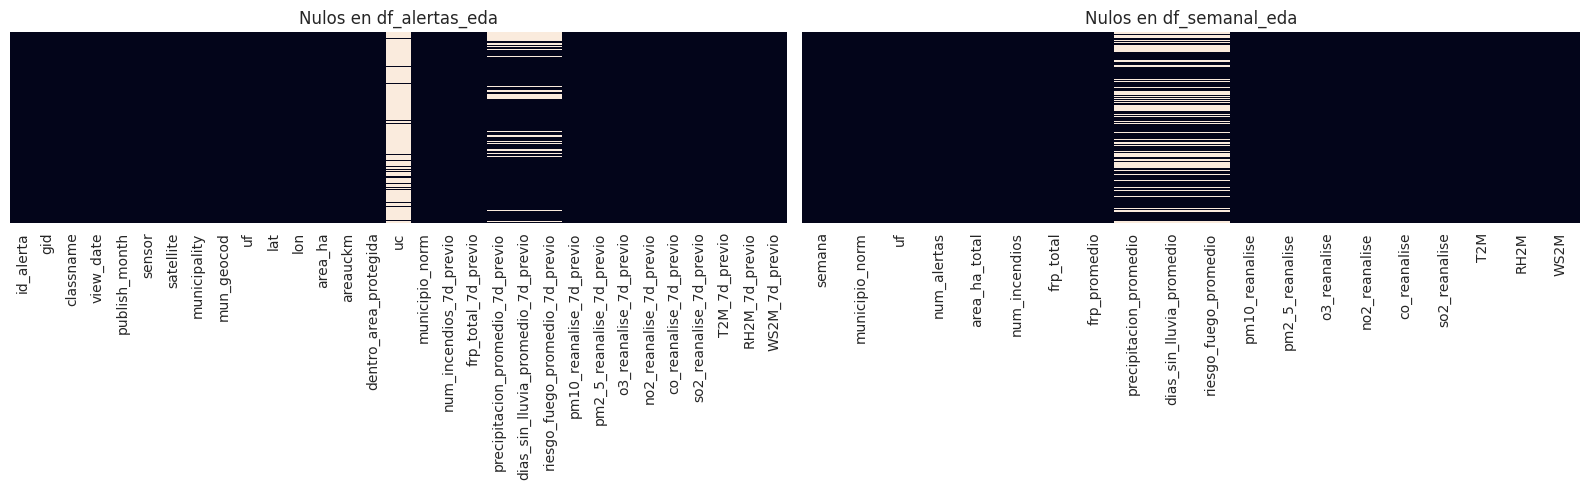

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.heatmap(df_alertas_eda.isnull(), cbar=False, yticklabels=False, ax=axes[0])
axes[0].set_title("Nulos en df_alertas_eda")

sns.heatmap(df_semanal_eda.isnull(), cbar=False, yticklabels=False, ax=axes[1])
axes[1].set_title("Nulos en df_semanal_eda")

plt.tight_layout()
plt.show()

## 3. Identificación de valores atípicos (outliers)

Se revisan las variables numéricas continuas con potencial de distorsionar el modelado: los dos targets, las variables climáticas de las 3 fuentes, y las variables de conteo/intensidad de incendios. Se excluyen identificadores, variables categóricas y coordenadas geográficas, donde el concepto de "outlier" no aplica de la misma forma.

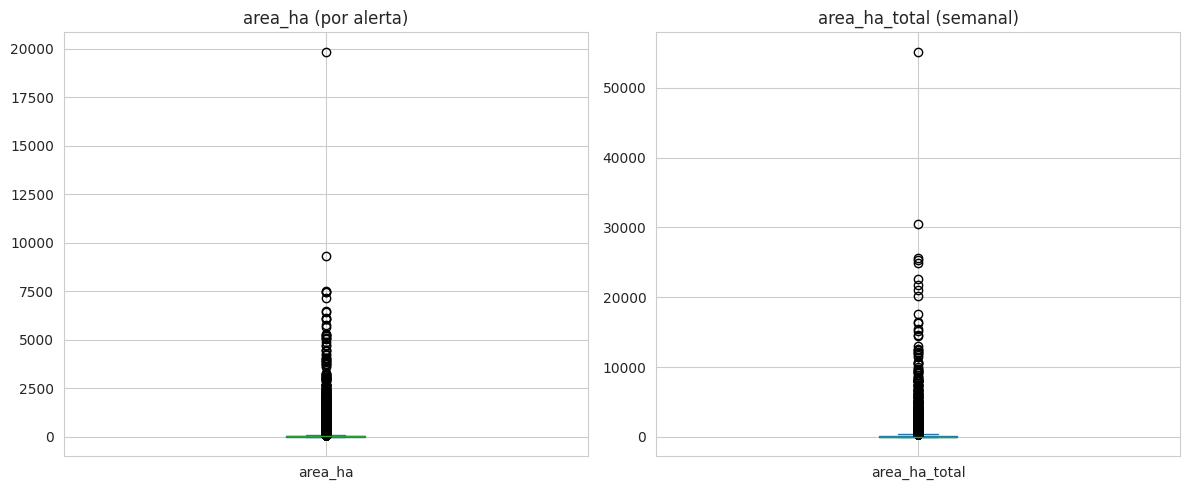

area_ha - top 5 valores más altos:
           municipio_norm  uf  view_date             classname   area_ha
11595              MANAUS  AM 2022-10-04            DEGRADACAO  19849.76
28867           QUERENCIA  MT 2024-05-05  CICATRIZ_DE_QUEIMADA   9314.30
44174  SAO FELIX DO XINGU  PA 2024-10-09  CICATRIZ_DE_QUEIMADA   7504.06
38904  SAO FELIX DO XINGU  PA 2024-09-14  CICATRIZ_DE_QUEIMADA   7485.36
16047         FELIZ NATAL  MT 2023-05-10      DESMATAMENTO_VEG   7456.85

area_ha_total - top 5 valores más altos:
            municipio_norm  uf     semana  num_alertas  area_ha_total
10337   SAO FELIX DO XINGU  PA 2024-09-23          390       55192.06
10598   SAO FELIX DO XINGU  PA 2024-10-07          125       30497.04
10248      CUMARU DO NORTE  PA 2024-09-23          101       25583.98
10303  OURILANDIA DO NORTE  PA 2024-09-23          152       25306.00
10431       NOVO PROGRESSO  PA 2024-09-30          146       24919.55


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

df_alertas_eda["area_ha"].plot(kind="box", ax=axes[0], title="area_ha (por alerta)")
df_semanal_eda["area_ha_total"].plot(kind="box", ax=axes[1], title="area_ha_total (semanal)")

plt.tight_layout()
plt.show()

print("area_ha - top 5 valores más altos:")
print(df_alertas_eda.nlargest(5, "area_ha")[["municipio_norm", "uf", "view_date", "classname", "area_ha"]])

print("\narea_ha_total - top 5 valores más altos:")
print(df_semanal_eda.nlargest(5, "area_ha_total")[["municipio_norm", "uf", "semana", "num_alertas", "area_ha_total"]])

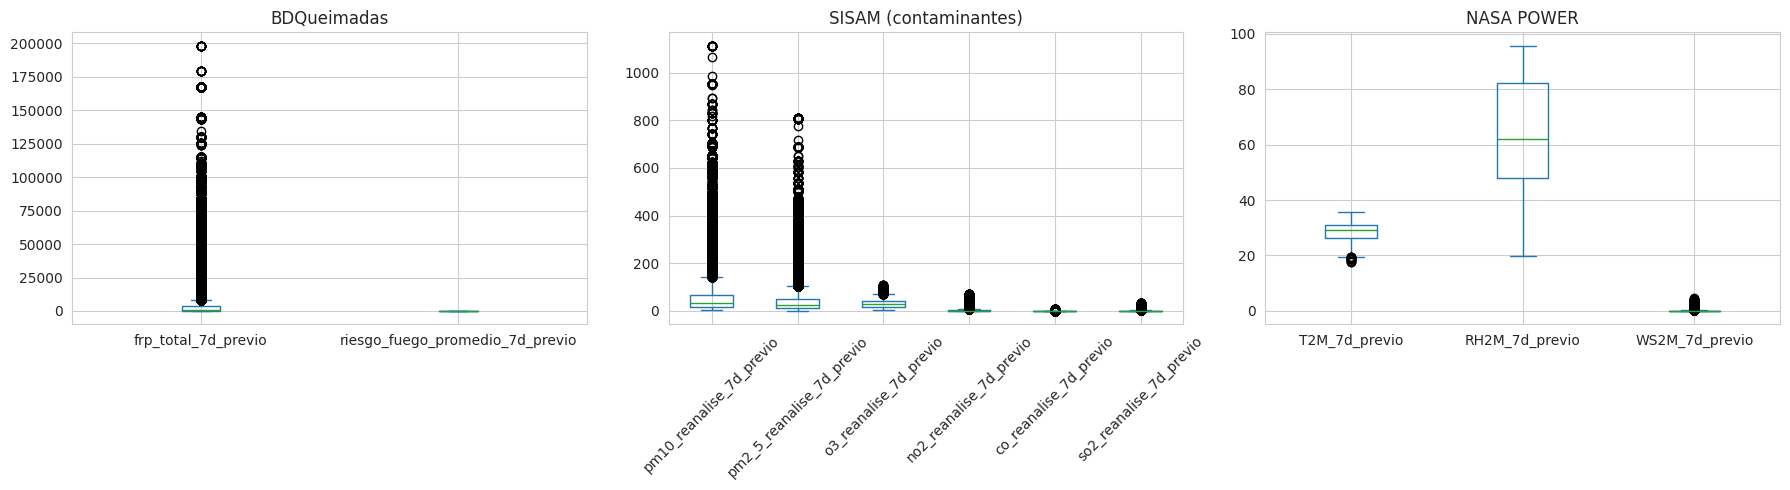

In [ ]:
cols_bdqueimadas = ["frp_total_7d_previo", "riesgo_fuego_promedio_7d_previo"]
cols_sisam = ["pm10_reanalise_7d_previo", "pm2_5_reanalise_7d_previo", "o3_reanalise_7d_previo",
              "no2_reanalise_7d_previo", "co_reanalise_7d_previo", "so2_reanalise_7d_previo"]
cols_nasa = ["T2M_7d_previo", "RH2M_7d_previo", "WS2M_7d_previo"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
df_alertas_eda[cols_bdqueimadas].plot(kind="box", ax=axes[0], title="BDQueimadas")
df_alertas_eda[cols_sisam].plot(kind="box", ax=axes[1], title="SISAM (contaminantes)", rot=45)
df_alertas_eda[cols_nasa].plot(kind="box", ax=axes[2], title="NASA POWER")
plt.tight_layout()
plt.show()

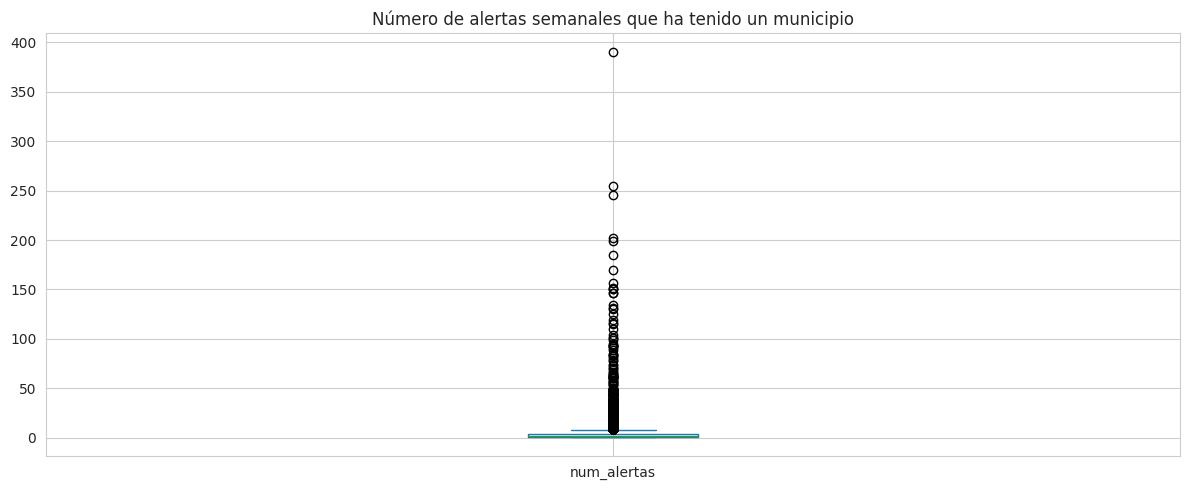

Top 5 semanas/municipios con más alertas:
           municipio_norm  uf     semana  num_alertas  area_ha_total
10337  SAO FELIX DO XINGU  PA 2024-09-23          390       55192.06
9875   SAO FELIX DO XINGU  PA 2024-09-02          255       15102.62
10026  SAO FELIX DO XINGU  PA 2024-09-09          246       21785.01
9749   SAO FELIX DO XINGU  PA 2024-08-26          202       12042.25
10566      NOVO PROGRESSO  PA 2024-10-07          199       20152.60


In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(12, 5))

df_semanal_eda["num_alertas"].plot(kind="box", ax=ax, title="Número de alertas semanales que ha tenido un municipio")
plt.tight_layout()
plt.show()
print("Top 5 semanas/municipios con más alertas:")
print(df_semanal_eda.nlargest(5, "num_alertas")[["municipio_norm", "uf", "semana", "num_alertas", "area_ha_total"]])

## Hallazgo: Valores atípicos (outliers)

### Targets (`area_ha`, `area_ha_total`)

Ambos targets muestran una distribución fuertemente asimétrica, con una cola larga de eventos extremos muy por encima de la mediana (19.26 ha y 45.02 ha respectivamente). Al inspeccionar los casos concretos, se identifican dos grupos distintos:

- **Eventos extremos plausibles:** la mayoría de los outliers de `area_ha` y prácticamente todos los de `area_ha_total` se concentran en municipios del sur de Pará (São Félix do Xingu, Cumaru do Norte, Ourilândia do Norte, Novo Progresso) durante septiembre-octubre de 2024 — periodo que coincide exactamente con la temporada de incendios más severa jamás registrada en la Amazonía (WRI, 2025, ya citado en el Resumen Ejecutivo). El caso máximo de `num_alertas` (390 alertas en una sola semana, São Félix do Xingu, semana del 23/09/2024) es consistente con este mismo evento real de gran escala, no con un error de datos.
- **Un caso atípico que amerita revisión puntual:** la alerta de mayor `area_ha` (19,849.76 ha, Manaus, clasificada como `DEGRADACAO`) se distancia notablemente del segundo valor más alto (9,314.30 ha) —más del doble— y ocurre en un municipio predominantemente urbano, no en el "arco de deforestación" donde se concentran los demás extremos. Se marca como pendiente de verificación en Data Preparation (posible artefacto de geometría o polígono mal delimitado), en lugar de asumirse automáticamente como un evento real.

### Variables climáticas

- **BDQueimadas (`frp_total_7d_previo`):** outliers hasta ~198,000 MW, consistentes con la acumulación de muchos focos de calor simultáneos en los mismos municipios/semanas ya identificados como hotspots reales.
- **SISAM (`pm10_reanalise_7d_previo`, `pm2_5_reanalise_7d_previo`):** valores extremos superiores a 1,000 µg/m³, coherentes con episodios de humo intenso documentados durante la temporada de quemas 2024. El resto de contaminantes (O3, NO2, CO, SO2) muestra una dispersión de outliers proporcionalmente menor.
- **NASA POWER:** `T2M_7d_previo` presenta pocos outliers hacia temperaturas bajas (eventos de "friagem", ya documentados como fenómeno real de la región); `WS2M_7d_previo` muestra outliers hacia vientos altos; `RH2M_7d_previo` no presenta outliers marcados, solo amplia dispersión natural.

**Nota técnica de visualización:** `frp_total_7d_previo` y `riesgo_fuego_promedio_7d_previo` no deben graficarse en la misma escala (el segundo está acotado entre 0 y 1), ya que esto oculta visualmente su distribución — se recomienda un boxplot separado por unidad de medida.

**Conclusión:** la gran mayoría de los valores atípicos identificados corresponden a eventos reales de gran magnitud, no a errores de captura, y están respaldados por el contexto documentado en el Resumen Ejecutivo (2024 como año récord de incendios). El tratamiento (transformación logarítmica de los targets, decisión sobre el caso de Manaus) se define en Data Preparation (Hito 2).

In [ ]:
alerta_manaus = df_alertas_eda[df_alertas_eda["municipio_norm"] == "MANAUS"].sort_values("area_ha", ascending=False)
print(alerta_manaus[["id_alerta", "gid", "classname", "view_date", "area_ha", "dentro_area_protegida"]].head(10))

       id_alerta         gid             classname  view_date   area_ha  \
11595      43814  13086_hist            DEGRADACAO 2022-10-04  19849.76   
11602      47791  13154_hist            DEGRADACAO 2022-10-04   1044.71   
43502      48054  34207_hist  CICATRIZ_DE_QUEIMADA 2024-10-08     51.66   
11679      30384  13020_hist       DESMATAMENTO_CR 2022-10-04     39.62   
46337      32398  41584_hist       DESMATAMENTO_CR 2024-10-18     32.70   
23527      15146  18030_hist       DESMATAMENTO_CR 2023-10-29     32.42   
31121      49007  52299_hist            DEGRADACAO 2024-07-12     28.76   
11556      40400  13104_hist       DESMATAMENTO_CR 2022-10-04     27.26   
49597      30987  52424_hist  CICATRIZ_DE_QUEIMADA 2024-12-02     25.73   
22594      15868  14732_hist  CICATRIZ_DE_QUEIMADA 2023-10-18     24.06   

       dentro_area_protegida  
11595                      0  
11602                      0  
43502                      0  
11679                      0  
46337              

## Hallazgo adicional: patrón sistemático en Manaus, no un caso aislado

Al aislar todas las alertas de Manaus, se observa que las **2 alertas de mayor área** (19,849.76 ha y 1,044.71 ha) comparten:
- El mismo municipio (Manaus, AM)
- La misma fecha exacta de detección (2022-10-04)
- La misma clase (`DEGRADACAO`)

Mientras que el resto de alertas del mismo municipio cae en rangos normales (25-52 ha, consistentes con la distribución general). Esta coincidencia —misma fecha, mismo municipio, misma clase, para las 2 únicas alertas verdaderamente extremas— sugiere un **posible artefacto de procesamiento de la escena satelital de ese día** (por ejemplo, un polígono mal segmentado que fusionó múltiples parcelas en una sola geometría, o un error de clasificación de nubes/sombra como degradación), más que un evento real de esa magnitud en un municipio predominantemente urbano.

**Se documenta como caso a tratar explícitamente en Data Preparation** (Hito 2): opciones a evaluar incluyen su exclusión justificada del conjunto de entrenamiento, o su conservación acompañada de una transformación robusta (logarítmica) que limite su influencia sobre el modelo sin eliminarlo del análisis.

## 4. Análisis de correlaciones y patrones multivariados


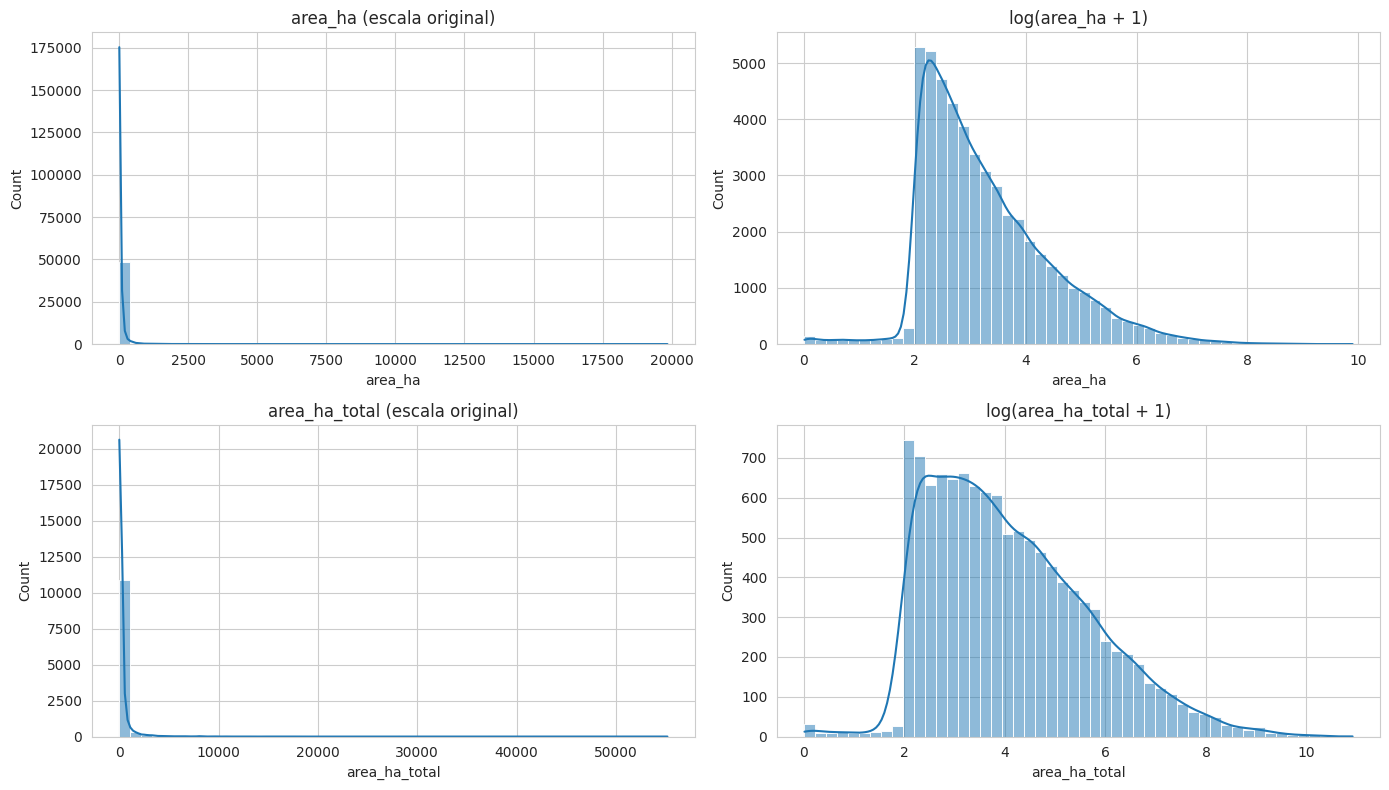

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

sns.histplot(df_alertas_eda["area_ha"], bins=50, kde=True, ax=axes[0,0])
axes[0,0].set_title("area_ha (escala original)")

sns.histplot(np.log1p(df_alertas_eda["area_ha"]), bins=50, kde=True, ax=axes[0,1])
axes[0,1].set_title("log(area_ha + 1)")

sns.histplot(df_semanal_eda["area_ha_total"], bins=50, kde=True, ax=axes[1,0])
axes[1,0].set_title("area_ha_total (escala original)")

sns.histplot(np.log1p(df_semanal_eda["area_ha_total"]), bins=50, kde=True, ax=axes[1,1])
axes[1,1].set_title("log(area_ha_total + 1)")

plt.tight_layout()
plt.show()

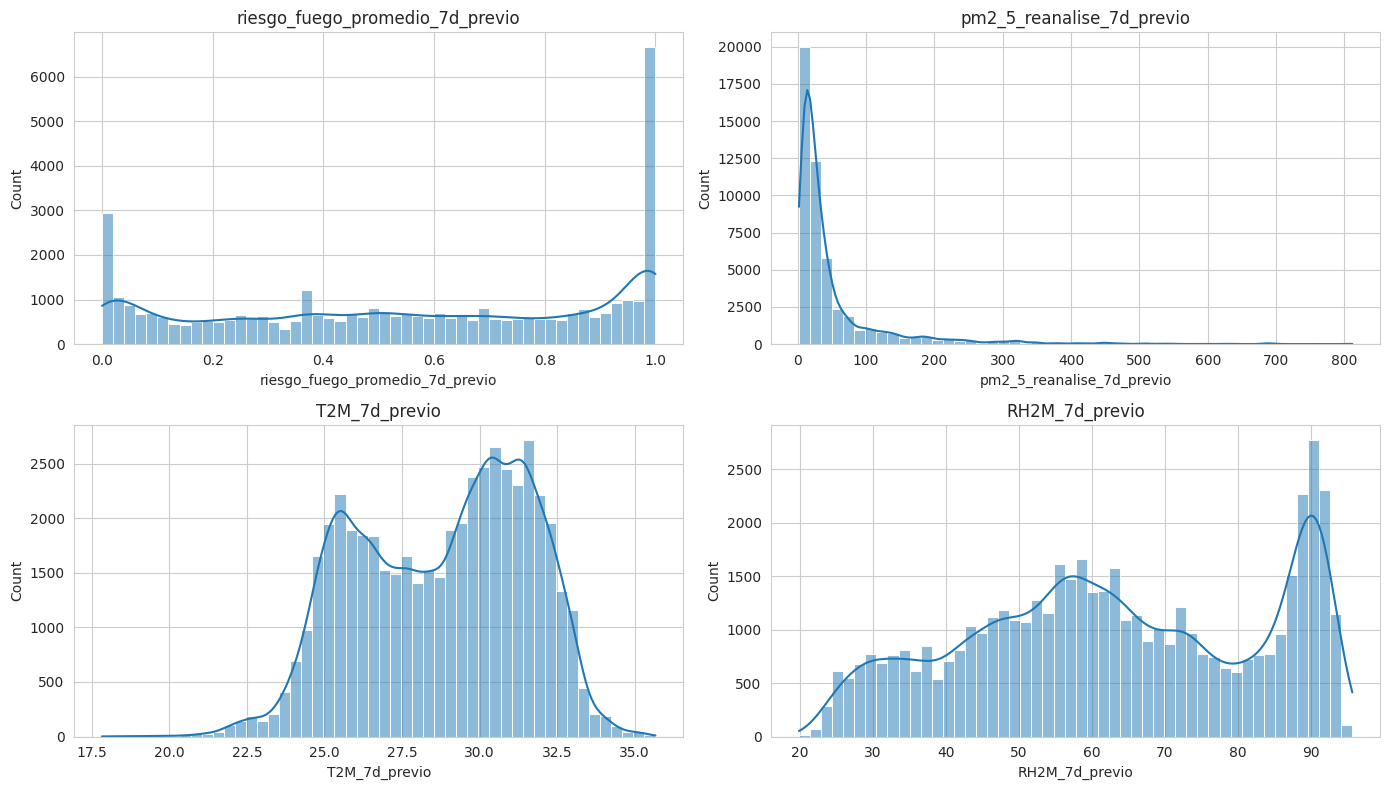

In [ ]:
cols_clima_hist = ["riesgo_fuego_promedio_7d_previo", "pm2_5_reanalise_7d_previo", "T2M_7d_previo", "RH2M_7d_previo"]

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for ax, col in zip(axes.flatten(), cols_clima_hist):
    sns.histplot(df_alertas_eda[col].dropna(), bins=50, kde=True, ax=ax)
    ax.set_title(col)

plt.tight_layout()
plt.show()

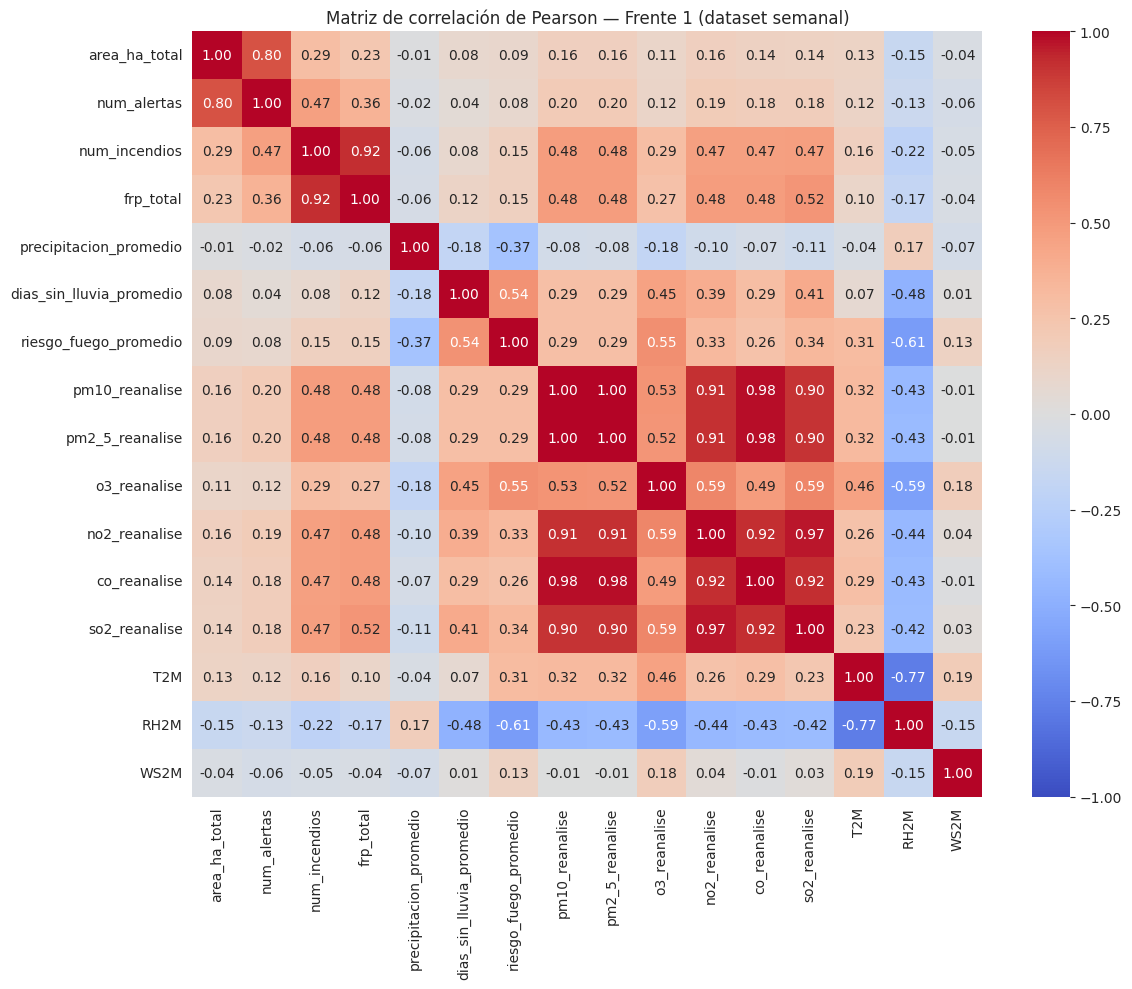

Correlación de cada variable con area_ha_total, ordenada:


,area_ha_total
area_ha_total,1.000000
num_alertas,0.804233
num_incendios,0.290124
frp_total,0.228634
pm10_reanalise,0.162832
pm2_5_reanalise,0.162553
no2_reanalise,0.156489
co_reanalise,0.142658
so2_reanalise,0.139643
T2M,0.129881


In [ ]:
cols_correlacion = ["area_ha_total", "num_alertas", "num_incendios", "frp_total",
                     "precipitacion_promedio", "dias_sin_lluvia_promedio", "riesgo_fuego_promedio",
                     "pm10_reanalise", "pm2_5_reanalise", "o3_reanalise", "no2_reanalise",
                     "co_reanalise", "so2_reanalise", "T2M", "RH2M", "WS2M"]

matriz_corr = df_semanal_eda[cols_correlacion].corr(method="pearson")

plt.figure(figsize=(12, 10))
sns.heatmap(matriz_corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1)
plt.title("Matriz de correlación de Pearson — Frente 1 (dataset semanal)")
plt.tight_layout()
plt.show()

print("Correlación de cada variable con area_ha_total, ordenada:")
matriz_corr["area_ha_total"].sort_values(ascending=False)

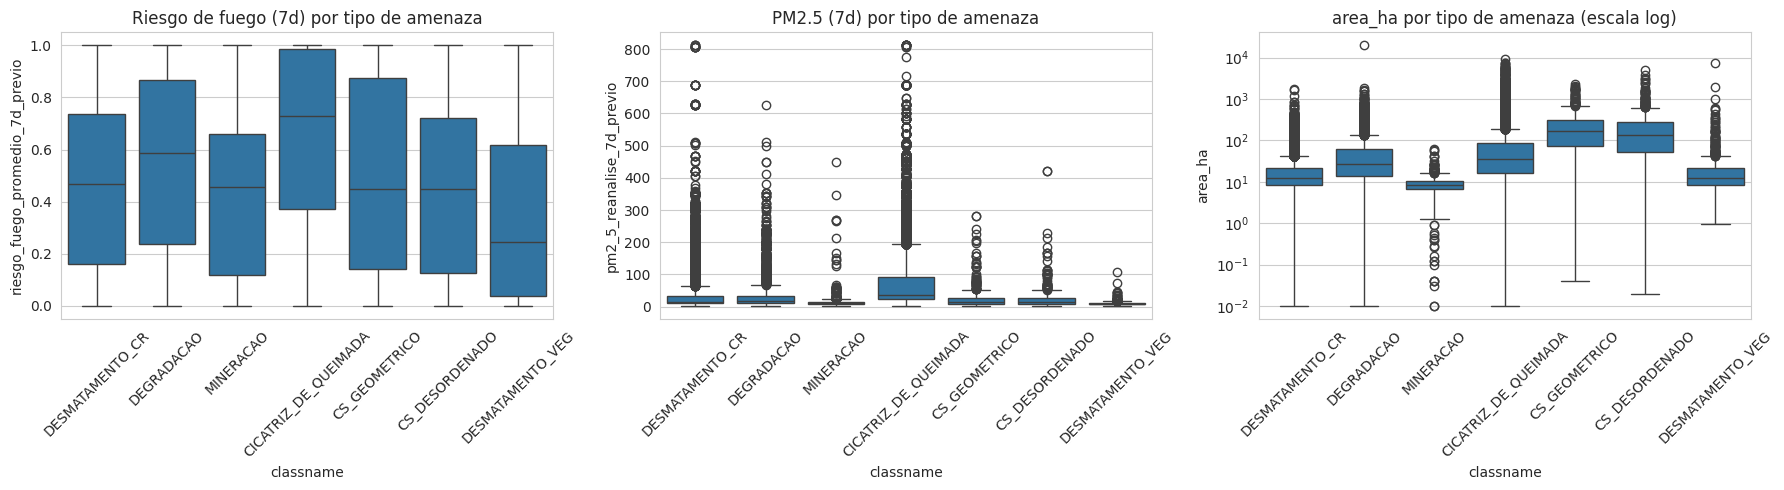

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.boxplot(data=df_alertas_eda, x="classname", y="riesgo_fuego_promedio_7d_previo", ax=axes[0])
axes[0].set_title("Riesgo de fuego (7d) por tipo de amenaza")
axes[0].tick_params(axis="x", rotation=45)

sns.boxplot(data=df_alertas_eda, x="classname", y="pm2_5_reanalise_7d_previo", ax=axes[1])
axes[1].set_title("PM2.5 (7d) por tipo de amenaza")
axes[1].tick_params(axis="x", rotation=45)

sns.boxplot(data=df_alertas_eda, x="classname", y="area_ha", ax=axes[2])
axes[2].set_title("area_ha por tipo de amenaza (escala log)")
axes[2].set_yscale("log")
axes[2].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

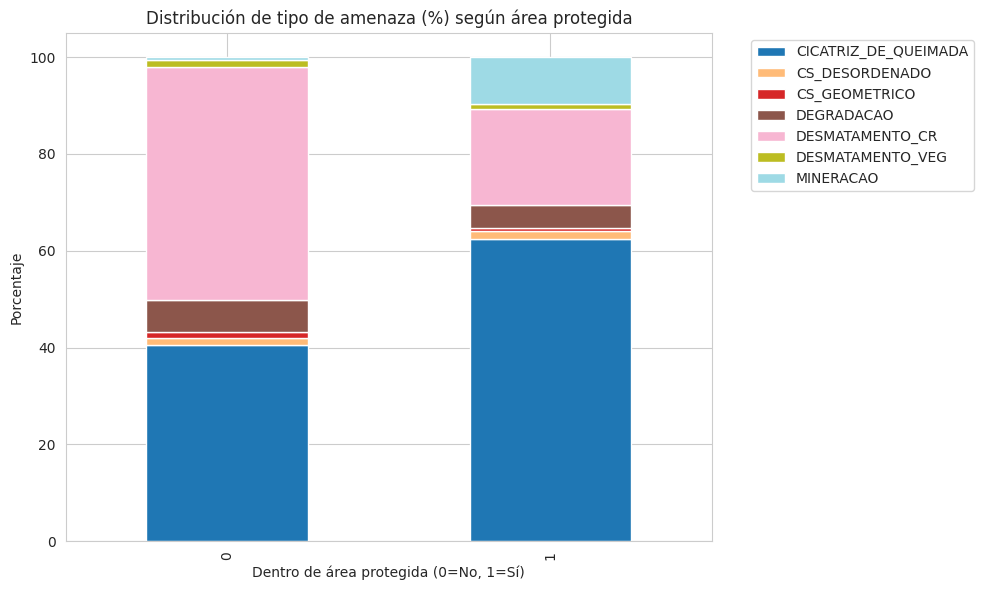

classname,CICATRIZ_DE_QUEIMADA,CS_DESORDENADO,CS_GEOMETRICO,DEGRADACAO,DESMATAMENTO_CR,DESMATAMENTO_VEG,MINERACAO
dentro_area_protegida,,,,,,,
0,40.58,1.42,1.27,6.56,48.12,1.41,0.65
1,62.37,1.77,0.51,4.82,19.83,0.94,9.76


In [ ]:
tabla_ap = pd.crosstab(df_alertas_eda["dentro_area_protegida"], df_alertas_eda["classname"], normalize="index") * 100

tabla_ap.plot(kind="bar", stacked=True, figsize=(10, 6), colormap="tab20")
plt.title("Distribución de tipo de amenaza (%) según área protegida")
plt.xlabel("Dentro de área protegida (0=No, 1=Sí)")
plt.ylabel("Porcentaje")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

tabla_ap.round(2)

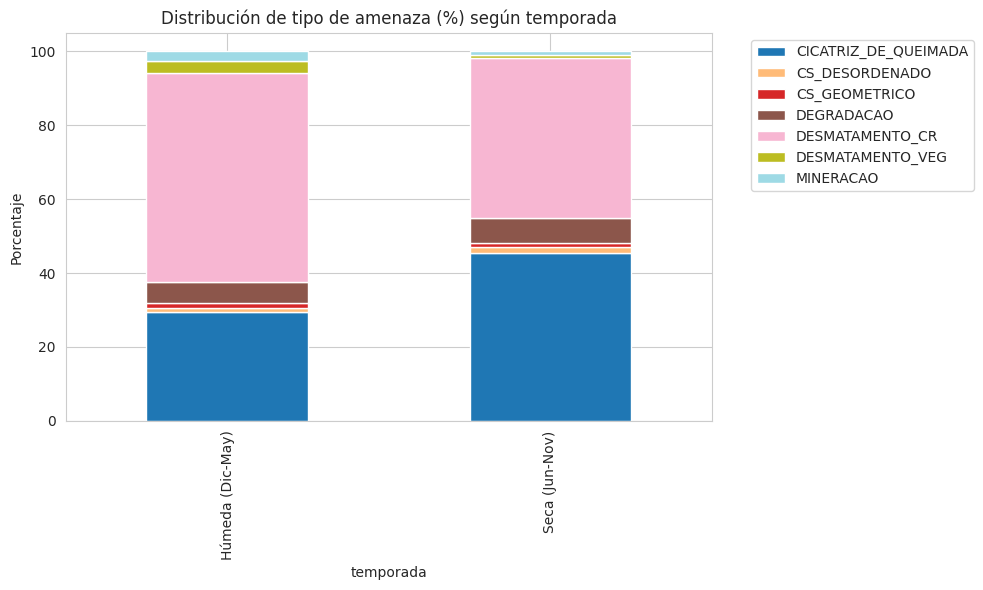

classname,CICATRIZ_DE_QUEIMADA,CS_DESORDENADO,CS_GEOMETRICO,DEGRADACAO,DESMATAMENTO_CR,DESMATAMENTO_VEG,MINERACAO
temporada,,,,,,,
Húmeda (Dic-May),29.43,1.08,1.44,5.62,56.52,3.22,2.70
Seca (Jun-Nov),45.42,1.54,1.16,6.65,43.42,0.90,0.92


In [ ]:
df_alertas_eda["mes"] = df_alertas_eda["view_date"].dt.month
df_alertas_eda["temporada"] = df_alertas_eda["mes"].apply(lambda m: "Seca (Jun-Nov)" if 6 <= m <= 11 else "Húmeda (Dic-May)")

tabla_temp = pd.crosstab(df_alertas_eda["temporada"], df_alertas_eda["classname"], normalize="index") * 100

tabla_temp.plot(kind="bar", stacked=True, figsize=(10, 6), colormap="tab20")
plt.title("Distribución de tipo de amenaza (%) según temporada")
plt.ylabel("Porcentaje")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

tabla_temp.round(2)

## Hallazgo: distribuciones, correlaciones y patrones multivariados

### Distribuciones (histogramas/densidad)

- **`area_ha` y `area_ha_total`** confirman la asimetría extrema ya identificada en outliers: en escala original, más del 90% de las observaciones se concentra visualmente en una sola barra cercana a cero. La transformación `log(x+1)` corrige esto, revelando una distribución mucho más manejable, cercana a una log-normal con cola derecha moderada — confirma que la transformación logarítmica es la adecuada para el modelado en Data Preparation.
- **`riesgo_fuego_promedio_7d_previo`** muestra una distribución bimodal marcada: una concentración de alertas con riesgo muy bajo (~0) y otra, aún mayor, con riesgo muy alto (~1). Esto sugiere que el índice de INPE tiende a valores extremos más que a valores intermedios — importante para el Frente 2, ya que esta variable podría discriminar bien entre clases de riesgo si se conserva como feature.
- **`pm2_5_reanalise_7d_previo`** tiene una distribución fuertemente sesgada a la derecha (la mayoría de alertas ocurre con contaminación baja-moderada, con una cola de eventos de contaminación extrema) — candidata también a transformación logarítmica si se usa como feature numérica.
- **`T2M_7d_previo` y `RH2M_7d_previo`** muestran distribuciones bimodales, probablemente reflejando la diferencia entre temporada seca y húmeda (dos regímenes climáticos distintos en la Amazonía) más que una sola población homogénea — hallazgo que se profundiza con el cruce por temporada.

### Matriz de correlación de Pearson (Frente 1)

- **`num_alertas` (r=0.80)** es, por lejos, la variable más correlacionada con `area_ha_total` — resultado esperable (a más alertas, más área acumulada) y confirma consistencia interna del dataset, aunque no aporta valor predictivo nuevo real por ser casi tautológico.
- Entre las variables climáticas, ninguna supera r=0.20 en magnitud con `area_ha_total` — la correlación lineal directa es débil en todos los casos. Las más relevantes son `num_incendios` (r=0.29), `frp_total` (r=0.23), y los contaminantes de SISAM (`pm10`/`pm2.5` r≈0.16). `RH2M` es la única con correlación negativa notable (r=-0.15): a mayor humedad, menor área afectada, coherente con la intuición física (ambientes húmedos frenan la propagación de quemas).
- **Multicolinealidad fuerte detectada** entre variables de SISAM: `pm10_reanalise` y `pm2_5_reanalise` correlacionan casi perfectamente entre sí (r=1.00), y `co_reanalise` con ambas (r=0.98) — son, en la práctica, la misma señal repetida. `no2_reanalise` y `so2_reanalise` también correlacionan fuerte con este grupo (r=0.90-0.97). Esto es relevante para Data Preparation: usar las 6 variables de SISAM juntas en un modelo lineal introduciría redundancia severa; se recomienda evaluar selección de una o dos variables representativas (ej. PM2.5 y O3) o técnicas de reducción de dimensionalidad.
- **`T2M` y `RH2M` correlacionan fuertemente entre sí (r=-0.77)**: a mayor temperatura, menor humedad — relación física esperable, pero otro caso a vigilar por posible redundancia si ambas entran juntas al modelo.

### Boxplot multivariable: variables climáticas y área por tipo de amenaza (`classname`)

- **`MINERACAO`** se distingue con las medianas más bajas tanto en riesgo de fuego como en PM2.5 y área — consistente con que la minería no depende de condiciones de quema/sequía como las demás clases; es un proceso mecánico, no de combustión.
- **`CICATRIZ_DE_QUEIMADA`** muestra la mediana de riesgo de fuego más alta (~0.72) y un rango intercuartílico más compacto y elevado en PM2.5 — coherente con ser, por definición, la clase directamente asociada a eventos de quema.
- **`CS_GEOMETRICO`** y **`CS_DESORDENADO`** muestran las medianas de área más altas (~150-200 ha) — sorprendente, dado que se esperaría que el corte selectivo afecte áreas menores que la tala total; posible hipótesis a explorar en Data Preparation: estas clases podrían estar capturando concesiones forestales de gran extensión con polígonos agregados, no necesariamente parcelas individuales pequeñas.

### Gráficos de barras apiladas al 100%

**`classname` según área protegida** (confirma y cuantifica el hallazgo encontrado en la limpieza de datos):
- `MINERACAO` pasa de representar 0.65% de las alertas fuera de área protegida a **9.76% dentro de ella** — un incremento de 15 veces, la asociación más fuerte de toda la tabla.
- `DESMATAMENTO_CR` cae de 48.12% (fuera) a 19.83% (dentro) — la tala total es proporcionalmente menos común dentro de áreas protegidas, posiblemente por mayor vigilancia formal en esas zonas.
- `CICATRIZ_DE_QUEIMADA` aumenta de 40.58% a 62.37% dentro de área protegida.

**`classname` según temporada** (nuevo hallazgo, no explorado antes):
- `MINERACAO` es 3 veces más frecuente en temporada húmeda (2.70%) que en temporada seca (0.92%) — patrón inverso al que se esperaría si dependiera del clima seco, lo cual refuerza que la minería es un proceso independiente de las condiciones de combustión.
- `DESMATAMENTO_VEG` también es notablemente más frecuente en temporada húmeda (3.22% vs 0.90%).
- `CICATRIZ_DE_QUEIMADA`, como es esperable, es más frecuente en temporada seca (45.42% vs 29.43%) — consistente con la estacionalidad de incendios documentada en el Resumen Ejecutivo.

**Conclusión general:** existe evidencia consistente de que el tipo de amenaza (`classname`) está asociado tanto a la ubicación (área protegida) como a la temporada del año, y que las variables climáticas explican razonablemente bien esas asociaciones cuando se agrupan por clase, aunque su correlación lineal directa con el área afectada (Frente 1) es débil. Esto sugiere que el Frente 2 (clasificación) podría beneficiarse más de estas variables que el Frente 1 (regresión), y que el Frente 1 podría requerir features no lineales o de interacción (ej. combinaciones de sequía + temperatura) para capturar mejor la relación con `area_ha_total`.

In [ ]:
print((df_semanal_eda["pm10_reanalise"] == df_semanal_eda["pm2_5_reanalise"]).mean())
print(df_semanal_eda[["pm10_reanalise", "pm2_5_reanalise"]].head(10))

0.0
   pm10_reanalise  pm2_5_reanalise
0       23.165000        18.445000
1       20.620000        16.535000
2       23.300000        18.150000
3       20.710000        16.615000
4       23.650000        18.560000
5       17.022857        12.567143
6       24.222857        19.078571
7       18.478571        14.342857
8       17.408571        13.427143
9       28.972857        22.990000


### Verificación: correlación pm10/pm2.5 ≈ 1.00

Se verificó que `pm10_reanalise` y `pm2_5_reanalise` no son columnas duplicadas por error de pipeline (0% de filas idénticas). La correlación casi perfecta (r=1.00) es un resultado físicamente esperado, no un artefacto de datos: PM2.5 es por definición un subconjunto de PM10 (partículas de diámetro ≤2.5 µm dentro del total de partículas ≤10 µm), por lo que ambas series responden a la misma fuente de emisión (humo de biomasa) de forma casi proporcional. Esto refuerza —y no contradice— la recomendación de Data Preparation de seleccionar solo una de las dos como feature representativa del grupo, evitando redundancia sin perder información real.

## 5. Evolución temporal, distribución espacial y balance de clases

Estos tres análisis completan el EDA: la evolución temporal es esencial dado que el Frente 1 es explícitamente un problema de series temporales; la distribución espacial identifica dónde se concentra el fenómeno; y el balance de clases confirma formalmente el desbalance que se abordará con SMOTE en Data Preparation.

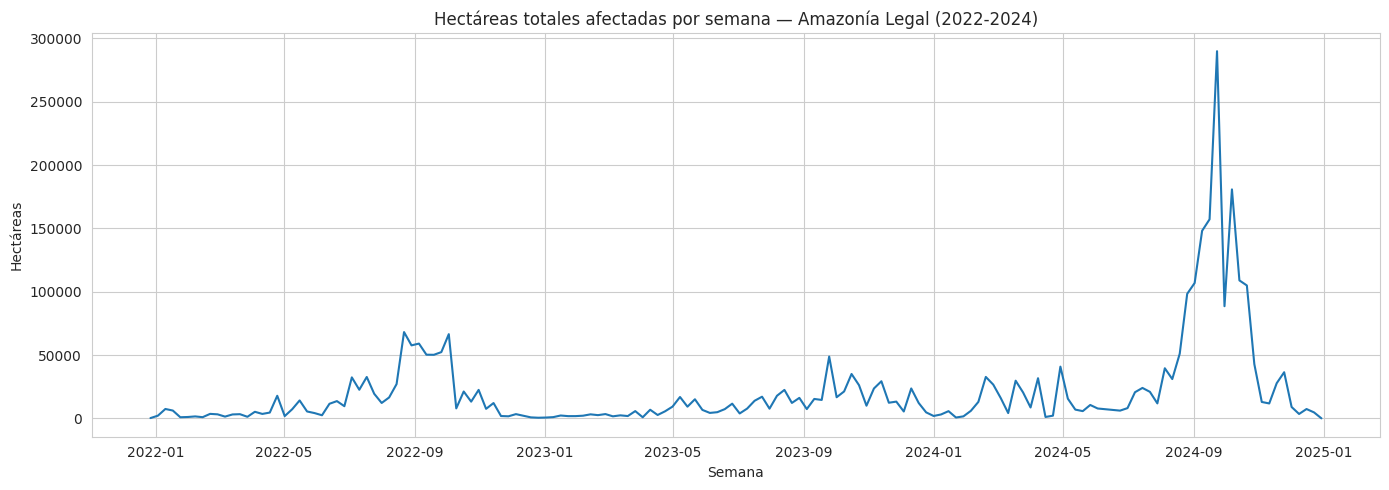

In [ ]:
serie_temporal = df_semanal_eda.groupby("semana")["area_ha_total"].sum().reset_index()

plt.figure(figsize=(14, 5))
plt.plot(serie_temporal["semana"], serie_temporal["area_ha_total"])
plt.title("Hectáreas totales afectadas por semana — Amazonía Legal (2022-2024)")
plt.xlabel("Semana")
plt.ylabel("Hectáreas")
plt.tight_layout()
plt.show()

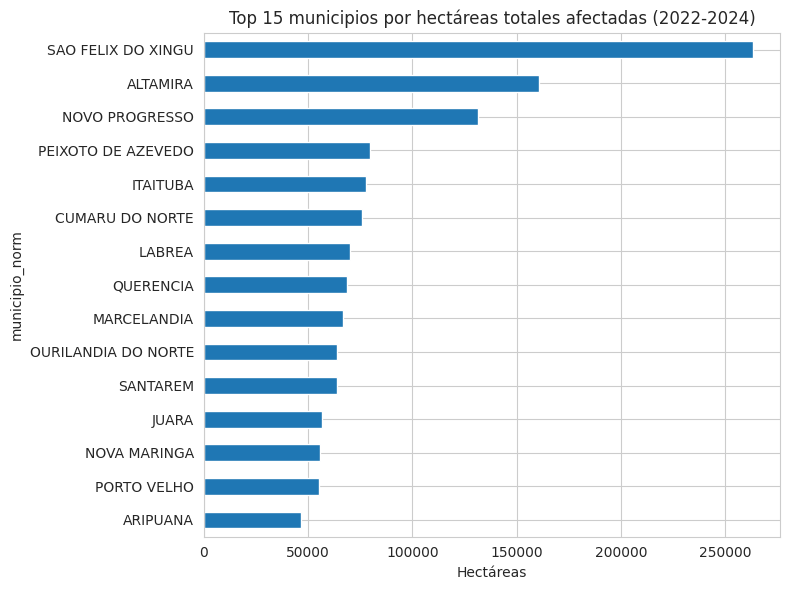

,area_ha_total
municipio_norm,
SAO FELIX DO XINGU,263018.36
ALTAMIRA,160474.71
NOVO PROGRESSO,131440.22
PEIXOTO DE AZEVEDO,79515.34
ITAITUBA,77717.61
CUMARU DO NORTE,75669.48
LABREA,69898.69
QUERENCIA,68731.93
MARCELANDIA,66766.27


In [ ]:
top_municipios = df_semanal_eda.groupby("municipio_norm")["area_ha_total"].sum().nlargest(15)

top_municipios.plot(kind="barh", figsize=(8, 6))
plt.title("Top 15 municipios por hectáreas totales afectadas (2022-2024)")
plt.xlabel("Hectáreas")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

top_municipios

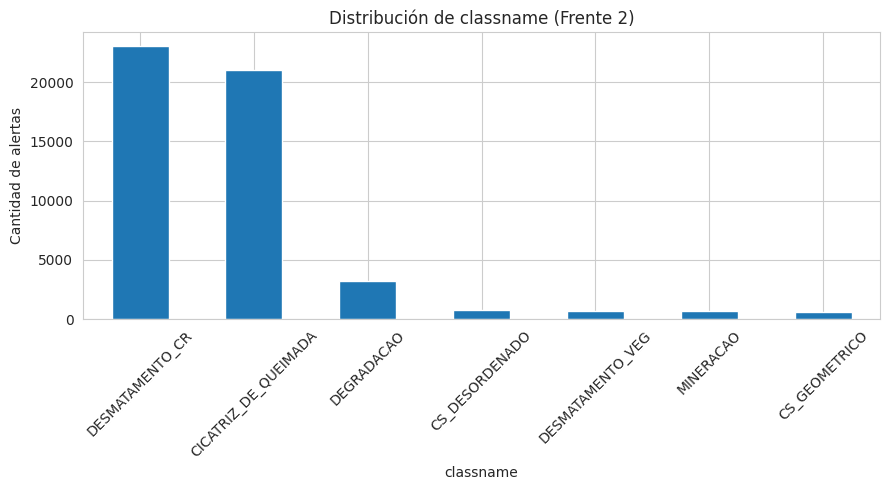

classname
DESMATAMENTO_CR         23054
CICATRIZ_DE_QUEIMADA    21041
DEGRADACAO               3215
CS_DESORDENADO            721
DESMATAMENTO_VEG          688
MINERACAO                 643
CS_GEOMETRICO             609
Name: count, dtype: int64

Porcentaje:
classname
DESMATAMENTO_CR         46.13
CICATRIZ_DE_QUEIMADA    42.11
DEGRADACAO               6.43
CS_DESORDENADO           1.44
DESMATAMENTO_VEG         1.38
MINERACAO                1.29
CS_GEOMETRICO            1.22
Name: count, dtype: float64


In [ ]:
conteo_clases = df_alertas_eda["classname"].value_counts()

conteo_clases.plot(kind="bar", figsize=(9, 5))
plt.title("Distribución de classname (Frente 2)")
plt.ylabel("Cantidad de alertas")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(conteo_clases)
print("\nPorcentaje:")
print((conteo_clases / len(df_alertas_eda) * 100).round(2))

Promedio general de alertas dentro de área protegida: 7.01%



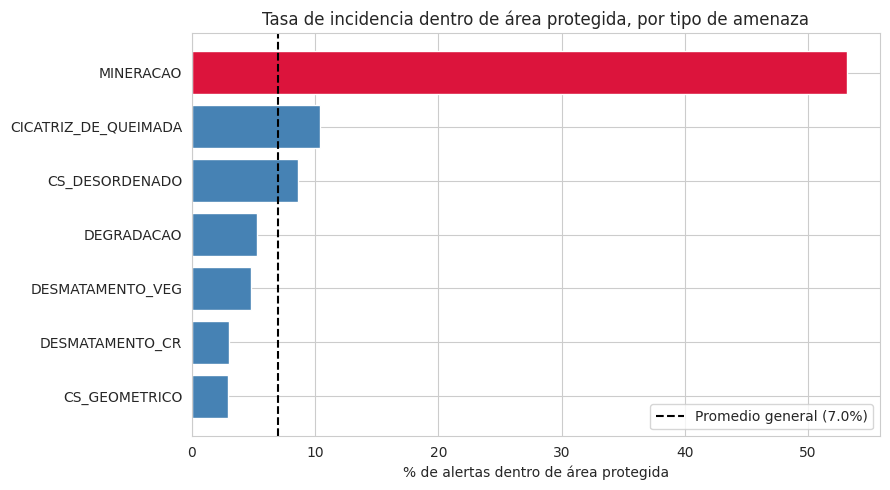

,frecuencia_en_ap,tasa_en_ap,veces_vs_promedio
classname,,,
MINERACAO,342,53.19,7.6
CICATRIZ_DE_QUEIMADA,2186,10.39,1.5
CS_DESORDENADO,62,8.60,1.2
DEGRADACAO,169,5.26,0.7
DESMATAMENTO_VEG,33,4.80,0.7
DESMATAMENTO_CR,695,3.01,0.4
CS_GEOMETRICO,18,2.96,0.4


In [ ]:
tabla_ap_detalle = (
    df_alertas_eda.groupby("classname")["dentro_area_protegida"]
    .agg(frecuencia_en_ap="sum", tasa_en_ap="mean")
    .assign(tasa_en_ap=lambda d: (d["tasa_en_ap"] * 100).round(2))
    .sort_values("tasa_en_ap", ascending=False)
)

promedio_general = df_alertas_eda["dentro_area_protegida"].mean() * 100
tabla_ap_detalle["veces_vs_promedio"] = (tabla_ap_detalle["tasa_en_ap"] / promedio_general).round(1)

print(f"Promedio general de alertas dentro de área protegida: {promedio_general:.2f}%\n")
tabla_ap_detalle

fig, ax = plt.subplots(figsize=(9, 5))
colores = ["crimson" if v > 3 else "steelblue" for v in tabla_ap_detalle["veces_vs_promedio"]]
ax.barh(tabla_ap_detalle.index, tabla_ap_detalle["tasa_en_ap"], color=colores)
ax.axvline(promedio_general, color="black", linestyle="--", label=f"Promedio general ({promedio_general:.1f}%)")
ax.set_xlabel("% de alertas dentro de área protegida")
ax.set_title("Tasa de incidencia dentro de área protegida, por tipo de amenaza")
ax.legend()
ax.invert_yaxis()
plt.tight_layout()
plt.show()
tabla_ap_detalle

## Hallazgo: Evolución temporal, distribución espacial y balance de clases

### Evolución temporal

La serie semanal de hectáreas afectadas confirma dos patrones esperados y uno crítico:

- **Estacionalidad clara:** se observan picos recurrentes cada año entre agosto y octubre (temporada seca), consistente con el hallazgo de la sección anterior (mayor frecuencia de `CICATRIZ_DE_QUEIMADA` en esa temporada).
- **Escalada progresiva año a año:** el pico de 2022 (~68,000 ha/semana) y el de 2023 (~50,000 ha/semana) son notablemente menores al pico de **2024, que alcanza casi 290,000 ha en una sola semana** — más de 4 veces el pico de cualquier año anterior.
- **2024 como evento atípico a nivel de todo el dataset, no solo de casos puntuales:** este pico masivo de septiembre-octubre de 2024 es la causa raíz de todos los outliers extremos identificados anteriormente (São Félix do Xingu, Novo Progresso, Cumaru do Norte, Ourilândia do Norte — todos concentrados exactamente en esas semanas). Esto **corrobora con datos propios** la cifra citada en el Resumen Ejecutivo: 2024 fue el año con mayor pérdida de bosque tropical jamás registrada, con los incendios como causa principal por primera vez (WRI, 2025). El hallazgo de outliers deja de verse como "datos raros a limpiar" y pasa a entenderse como el reflejo fiel de un evento real y documentado externamente — reforzando que **no deben eliminarse sin justificación**, solo tratarse con una transformación adecuada (logarítmica) en Data Preparation.

### Distribución espacial

El área afectada se concentra fuertemente en un pequeño grupo de municipios: **São Félix do Xingu (263,018 ha), Altamira (160,475 ha) y Novo Progresso (131,440 ha)** —todos en el estado de Pará— acumulan por sí solos más área que los siguientes 12 municipios del top 15 combinados. Esto es consistente con el "arco de deforestación" ampliamente documentado en la literatura amazónica, y sugiere que un despliegue real de BIODIVERSITY-GUARD debería priorizar sensores/brigadas en estas zonas específicas antes que distribuir recursos de forma homogénea.

### Balance de clases (Frente 2)

La distribución de `classname` confirma un desbalance considerable: **`DESMATAMENTO_CR` (46.13%) y `CICATRIZ_DE_QUEIMADA` (42.11%) concentran el 88.24% de todas las alertas**, mientras que las 5 clases restantes (incluyendo `MINERACAO`, la de mayor relevancia para áreas protegidas) representan en conjunto solo el 11.76%. Este desbalance justifica formalmente el uso de técnicas de rebalanceo (SMOTE) en Data Preparation, con atención especial a no perder la capacidad del modelo de detectar la clase minoritaria `MINERACAO`, pese a representar apenas el 1.29% del total.

### Relación entre tipo de amenaza y área protegida (versión final, corregida)

Con el dataset ya corregido (snapshot congelado, clave `municipio_norm + uf`), se confirma con precisión el hallazgo detectado desde la fase de limpieza: **`MINERACAO` ocurre dentro de área protegida en el 53.19% de los casos, 7.6 veces más que el promedio general del dataset (7.01%)**. Ninguna otra clase se acerca a esta magnitud de asociación (la segunda más alta, `CICATRIZ_DE_QUEIMADA`, es solo 1.5 veces el promedio). Este hallazgo es el sustento empírico directo de la decisión, documentada en Data Preparation, de asignar a `MINERACAO` la mayor severidad base en la construcción del `Nivel_Riesgo_Amenaza`.